In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor,plot_tree 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from tqdm import tqdm
import os
os.chdir("/home/pgcp-ai/MachineLearning/Datasets/")

In [2]:
housing = pd.read_csv("Housing.csv")
housing

,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,42000.0,5850,3,1,2,yes,no,yes,no,no,1,no
1,38500.0,4000,2,1,1,yes,no,no,no,no,0,no
2,49500.0,3060,3,1,1,yes,no,no,no,no,0,no
3,60500.0,6650,3,1,2,yes,yes,no,no,no,0,no
4,61000.0,6360,2,1,1,yes,no,no,no,no,0,no
...,...,...,...,...,...,...,...,...,...,...,...,...
541,91500.0,4800,3,2,4,yes,yes,no,no,yes,0,no
542,94000.0,6000,3,2,4,yes,no,no,no,yes,0,no
543,103000.0,6000,3,2,4,yes,yes,no,no,yes,1,no
544,105000.0,6000,3,2,2,yes,yes,no,no,yes,1,no


In [3]:
housing.isna().sum()

price       0
lotsize     0
bedrooms    0
bathrms     0
stories     0
driveway    0
recroom     0
fullbase    0
gashw       0
airco       0
garagepl    0
prefarea    0
dtype: int64

In [4]:
X, y = housing.drop('price', axis = 1), housing["price"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state = 26)

In [6]:
ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown = 'ignore').set_output(transform = 'pandas')
transformer = ColumnTransformer(transformers=[('OHE',ohe,make_column_selector(dtype_include=object)),
                                            ]
                               ,remainder='passthrough',
                               verbose_feature_names_out=False
                               ).set_output(transform='pandas')

In [7]:
X_train_ohe = transformer.fit_transform(X_train)
X_test_ohe = transformer.transform(X_test)

In [8]:
depths = [1,2,3,4,5,6]
splits = []
scores = []
for d in tqdm(depths):
    dtc = DecisionTreeRegressor(max_depth=d,random_state=26)
    dtc.fit(X_train_ohe, y_train)
    y_pred = dtc.predict(X_test_ohe)
    scores.append([d,r2_score(y_test, y_pred)])
    
df_scores = pd.DataFrame(scores,columns=["Depth","R2 Score"])
df_scores.sort_values('R2 Score', ascending=False)

100%|████████████████████████████████████████████| 6/6 [00:00<00:00, 224.10it/s]


,Depth,R2 Score
4,5,0.475387
2,3,0.472958
1,2,0.427925
3,4,0.419193
5,6,0.368293
0,1,0.320453


In [9]:
depths = [1,2,3,4,5,6]
splits = [2,5,10,20,30]
scores = []
for s in tqdm(splits):
    dtc = DecisionTreeRegressor(min_samples_split=s,random_state=26)
    dtc.fit(X_train_ohe, y_train)
    y_pred = dtc.predict(X_test_ohe)
    scores.append([s,r2_score(y_test,y_pred)])
    
df_scores = pd.DataFrame(scores,columns=["Min Samples in each Node", "R2 Score"])
df_scores.sort_values('R2 Score', ascending = False)

100%|████████████████████████████████████████████| 5/5 [00:00<00:00, 126.66it/s]


,Min Samples in each Node,R2 Score
4,30,0.450151
3,20,0.445531
2,10,0.353734
1,5,0.290221
0,2,0.286557


In [10]:
depths = [1,2,3,4,5,6]
splits = [2,5,10,20,30]
scores = []
for s in tqdm(splits):
    for d in depths:
        dtc = DecisionTreeRegressor(min_samples_split=s,random_state=26,max_depth=d)
        dtc.fit(X_train_ohe, y_train)
        y_pred = dtc.predict(X_test_ohe)
        scores.append([d,s,r2_score(y_test,y_pred)])
    
df_scores = pd.DataFrame(scores,columns=["Depth","Min Samples in each Node","R2 Score"])
df_scores.sort_values('R2 Score', ascending = False)

100%|█████████████████████████████████████████████| 5/5 [00:00<00:00, 40.91it/s]


,Depth,Min Samples in each Node,R2 Score
4,5,2,0.475387
20,3,20,0.472958
2,3,2,0.472958
14,3,10,0.472958
26,3,30,0.472958
8,3,5,0.472958
22,5,20,0.472163
28,5,30,0.461402
10,5,5,0.456720
23,6,20,0.453552


In [11]:
depths = [1,2,3,4,5,6]
splits = [1,5,8,10,20]
scores = []
for s in tqdm(splits):
    dtc = DecisionTreeRegressor(min_samples_leaf=s,random_state=26)
    dtc.fit(X_train_ohe, y_train)
    y_pred = dtc.predict(X_test_ohe)
    scores.append([s,r2_score(y_test,y_pred)])
    
df_scores = pd.DataFrame(scores,columns=["Min Leaves in each Node","R2 Score"])
df_scores.sort_values("R2 Score", ascending = False)

100%|████████████████████████████████████████████| 5/5 [00:00<00:00, 193.90it/s]


,Min Leaves in each Node,R2 Score
4,20,0.526436
2,8,0.471378
3,10,0.467565
1,5,0.407415
0,1,0.286557


In [12]:
# depths= np.arange(1,7)
# splits = np.arange(2,25)
# leaves= np.arange(1,25)

depths = [1,2,3,5,None]
splits = [2,4,8,10,20,30,50,100]
leaves  = [1,4,8,10,20,30,45,46,50,100]

scores = []
for d in tqdm(depths):
    for s in splits:
        for l in leaves:     
            dtc = DecisionTreeRegressor(min_samples_split=s,random_state=26,max_depth=d,min_samples_leaf=l)
            dtc.fit(X_train_ohe, y_train)
            y_pred = dtc.predict(X_test_ohe)
            scores.append([d,s,l,r2_score(y_test, y_pred)])
df_scores = pd.DataFrame(scores,columns=["Depth","Min Samples in each Node to Split",'Min Samples in each Leaf Node',"R2 Score"])
df_scores.sort_values('R2 Score', ascending = False)

100%|█████████████████████████████████████████████| 5/5 [00:01<00:00,  3.60it/s]


,Depth,Min Samples in each Node to Split,Min Samples in each Leaf Node,R2 Score
304,5.0,50,20,0.530931
384,NaN,50,20,0.530931
382,NaN,50,8,0.528372
381,NaN,50,4,0.528372
383,NaN,50,10,0.528372
...,...,...,...,...
59,1.0,30,100,0.320453
60,1.0,50,1,0.320453
0,1.0,2,1,0.320453
330,NaN,4,1,0.305639


In [13]:
bm = DecisionTreeRegressor(random_state=26, max_depth = 5, min_samples_split=50, min_samples_leaf=20)
X_ohe = transformer.fit_transform(X)
bm.fit(X_ohe, y)

DecisionTreeRegressor(max_depth=5, min_samples_leaf=20, min_samples_split=50,
                      random_state=26)

In [14]:
list(X.columns)

['lotsize',
 'bedrooms',
 'bathrms',
 'stories',
 'driveway',
 'recroom',
 'fullbase',
 'gashw',
 'airco',
 'garagepl',
 'prefarea']

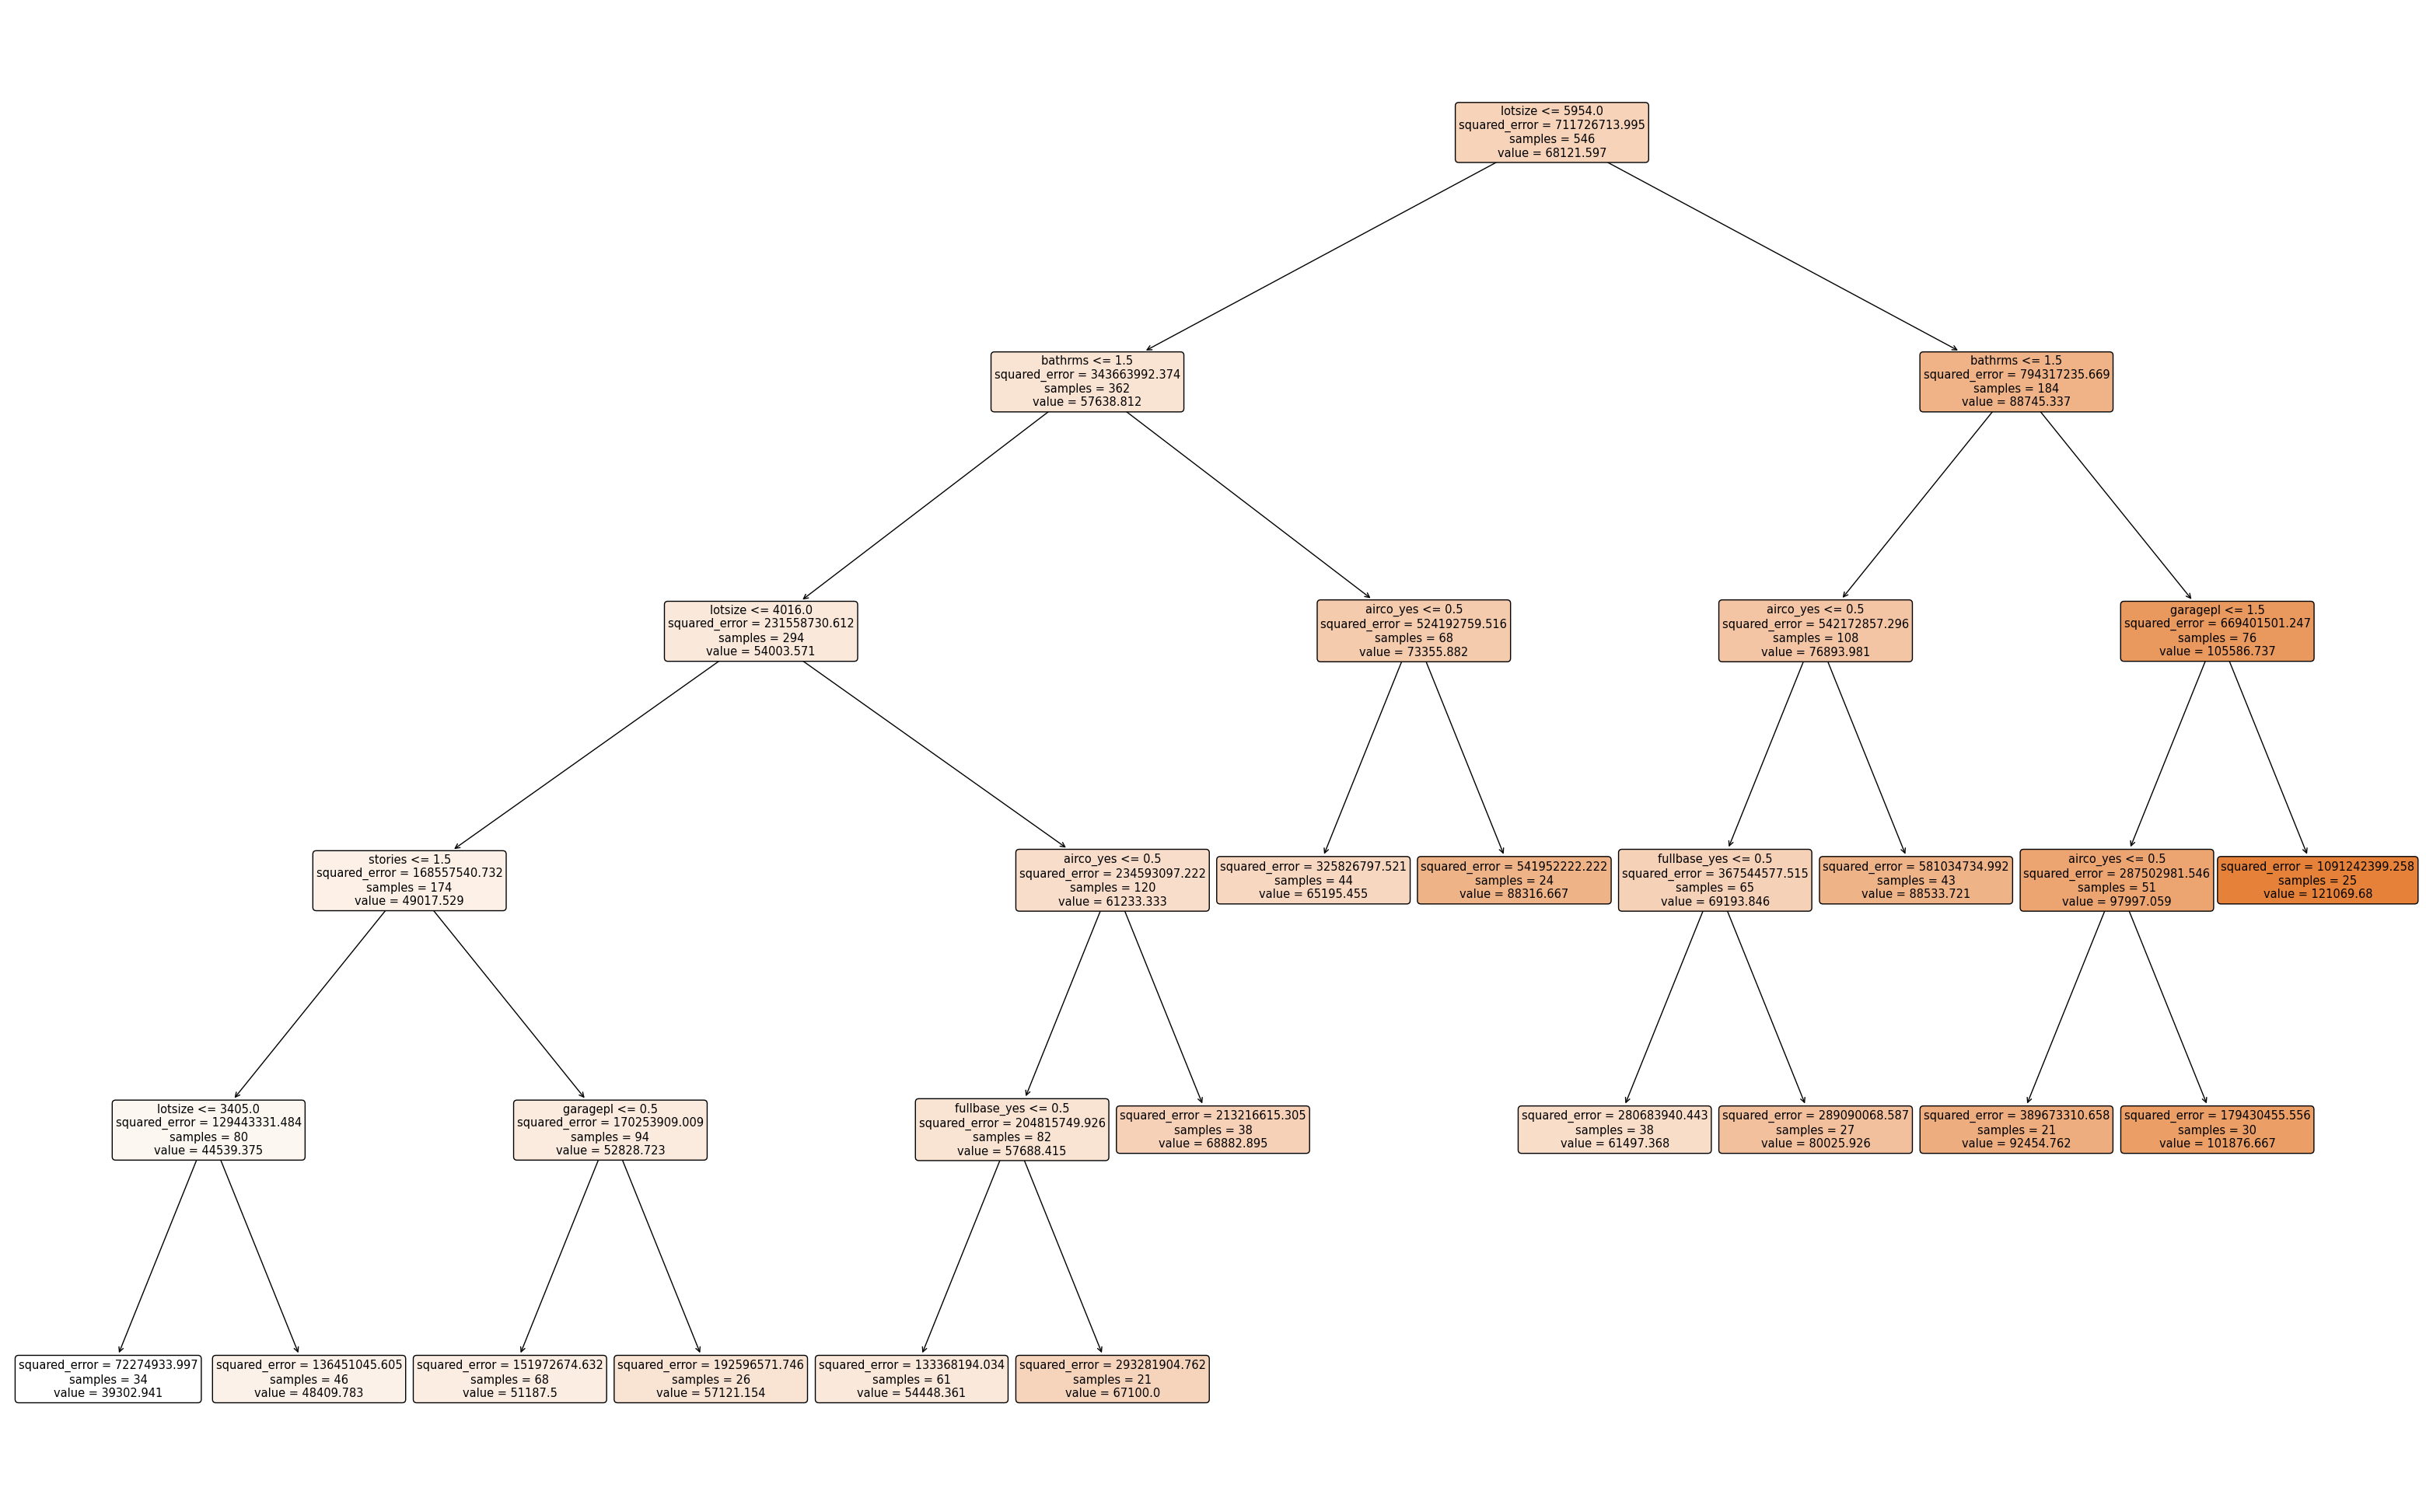

In [15]:
plt.figure(figsize = (40,25))
plot_tree(bm,filled=True, rounded = True,feature_names=list(X_ohe.columns))
plt.show()

In [16]:
bm.feature_importances_

array([0.        , 0.        , 0.03436022, 0.        , 0.09689299,
       0.        , 0.56516465, 0.        , 0.24907646, 0.01288452,
       0.04162115])

In [17]:
df_imp = pd.DataFrame({'feature':X_ohe.columns, 'Importance': bm.feature_importances_})
df_imp = df_imp.sort_values("Importance")

In [18]:
df_imp = df_imp.sort_values("Importance",ascending=False)
df_imp

,feature,Importance
6,lotsize,0.565165
8,bathrms,0.249076
4,airco_yes,0.096893
10,garagepl,0.041621
2,fullbase_yes,0.034360
9,stories,0.012885
0,driveway_yes,0.000000
1,recroom_yes,0.000000
3,gashw_yes,0.000000
5,prefarea_yes,0.000000


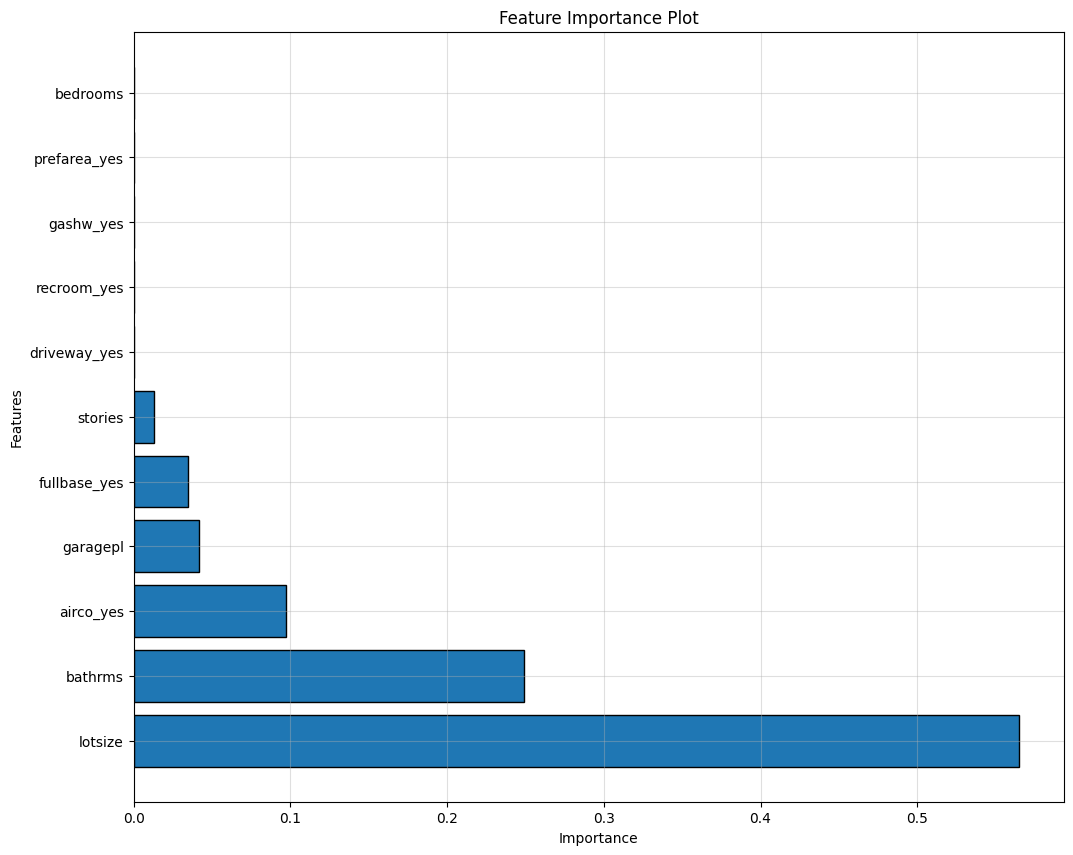

In [19]:
plt.figure(figsize=(12,10))
plt.barh(df_imp['feature'], df_imp['Importance'],ec='black')
plt.title('Feature Importance Plot')
plt.ylabel('Features')    
plt.xlabel('Importance')
# plt.xticks(rotation=45)
plt.grid(True,alpha=0.4)
plt.show()

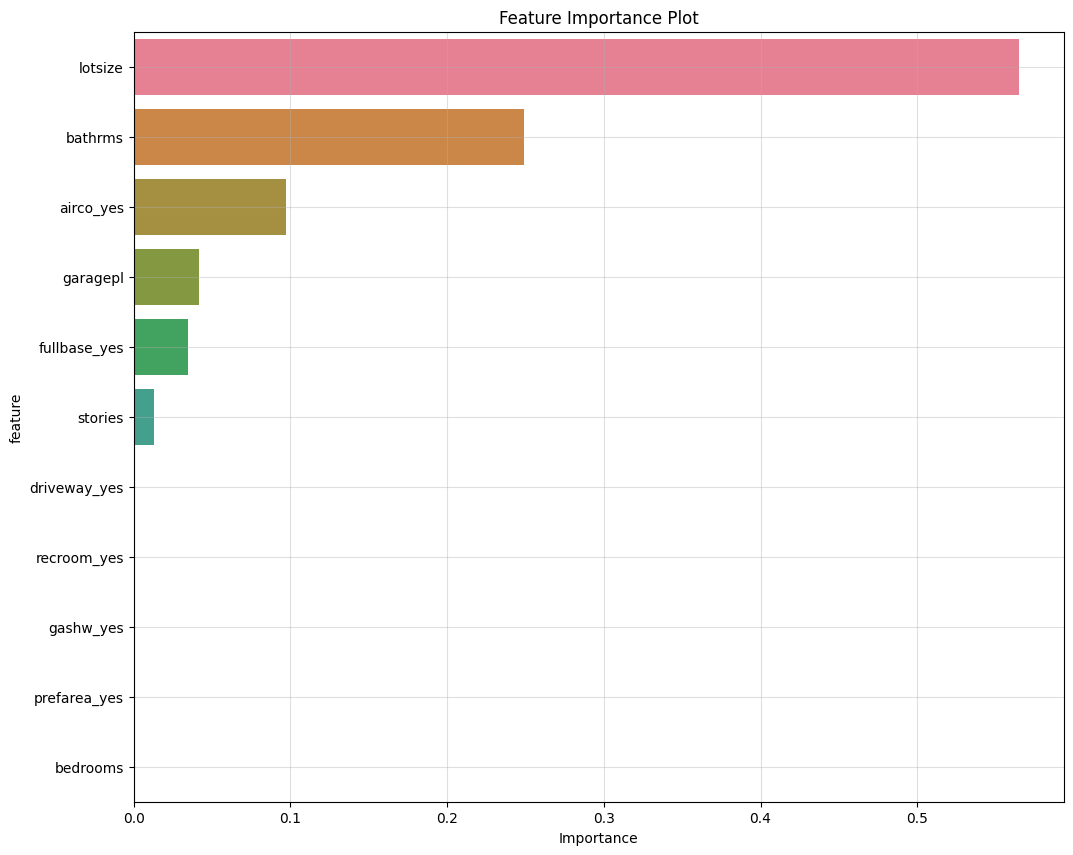

In [20]:
plt.figure(figsize=(12,10))
sns.barplot(data = df_imp,y='feature',x='Importance',hue='feature')
plt.title('Feature Importance Plot')
# plt.xlabel('Features')    
# plt.ylabel('Importance')
plt.grid(True,alpha=0.4)
plt.show()

In [21]:
l = len(X_train_ohe.columns)

In [26]:
features = np.arange(1,l+1)
scores = []
no_of_estimators = np.arange(25,126)
for f in tqdm(features):
    for n in no_of_estimators:
        rf = RandomForestRegressor(max_features=f,n_estimators=n,random_state=26)
        rf.fit(X_train_ohe,y_train)
        y_pred = rf.predict(X_test_ohe)
        scores.append([f,n,r2_score(y_test,y_pred)])
df_scores = pd.DataFrame(scores,columns=["No. of Features","No. of Estimators","R2 Score"])
df_scores.sort_values("R2 Score",ascending=False)

100%|███████████████████████████████████████████| 11/11 [02:04<00:00, 11.28s/it]


,No. of Features,No. of Estimators,R2 Score
82,1,107,0.699276
79,1,104,0.699201
74,1,99,0.699131
86,1,111,0.699093
85,1,110,0.698933
...,...,...,...
708,8,26,0.557373
1036,11,51,0.556937
709,8,27,0.554359
1010,11,25,0.554015


In [28]:
X = transformer.fit_transform(X)

In [29]:
bm = RandomForestRegressor(max_features = 1,n_estimators= 107,random_state=26)
bm.fit(X,y)

RandomForestRegressor(max_features=1, n_estimators=107, random_state=26)

In [30]:
df = pd.DataFrame({"Features":X.columns,"Importances":bm.feature_importances_})
df = df.sort_values('Importances',ascending=False)

<Axes: xlabel='Importances', ylabel='Features'>

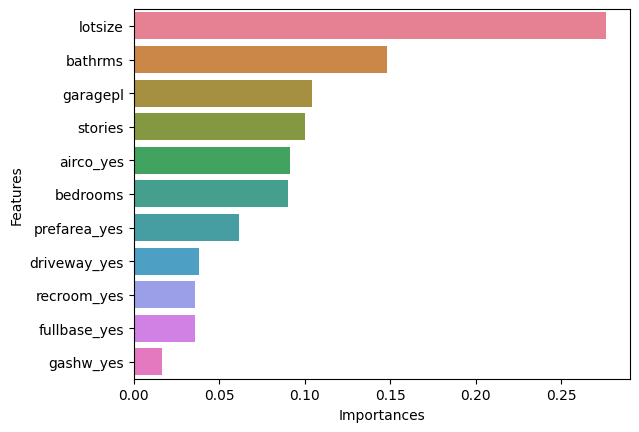

In [32]:
sns.barplot(data = df, x = "Importances", y = "Features", hue="Features")